這個實驗目標是測試不同策略搭配前面找到負相關的因子並持有第一群，看是否會提升收益
- 負相關因子 : ev_s、roe、pb、ps
- 策略逆勢布林通道、逢低買進、逆勢高低通道、順勢布林通道

In [1]:
from iplab.database import Database
from iplab.get_data import Data
from iplab import backtest
from iplab.combinations import sim_conditions
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data=Data()

In [3]:
# 取得各因子的第一群
factor_dict = {
    'ev_s': data.get('report:ev_s').divide_slice(quantile=10, ascending = True)['Quantile_1'], # 小到大
    'roe': data.get('report:roe').divide_slice(quantile=10, ascending = False)['Quantile_1'], # 大到小
    'pb': data.get('report:pb').divide_slice(quantile=10, ascending = True)['Quantile_1'], # 小到大
    'ps': data.get('report:ps').divide_slice(quantile=10, ascending = True)['Quantile_1'], # 小到大
    'p_ic': data.get('report:p_ic').divide_slice(quantile=10, ascending = True)['Quantile_1'], # 大到小 -> 小到大
}

In [5]:
single_factor_report_collection = sim_conditions(factor_dict, resample='M', data=data)

Backtesting progress:   0%|          | 0/5 [00:00<?, ?condition/s]

Backtesting progress: 100%|██████████| 5/5 [00:19<00:00,  3.99s/condition]


In [6]:
single_factor_report_collection.plot_stats(mode='heatmap')

,CAGR,daily_sharpe,max_drawdown,avg_drawdown,win_ratio,ytd
ev_s,0.200958,18.880000,-0.391411,-0.097864,0.427536,0.343758
ps,0.123183,19.060000,-0.290217,-0.037445,0.382643,0.345905
roe,0.121092,21.610000,-0.441242,-0.064247,0.383386,0.349562
pb,0.121091,18.480000,-0.288959,-0.024608,0.537529,0.282555
p_ic,0.115771,20.650000,-0.295363,-0.042661,0.438182,0.235029


In [32]:
result_df = single_factor_report_collection.stats.T
result_df

,CAGR,daily_sharpe,max_drawdown,avg_drawdown,win_ratio,ytd
ev_s,0.200958,18.88,-0.391411,-0.097864,0.427536,0.343758
roe,0.121092,21.61,-0.441242,-0.064247,0.383386,0.349562
pb,0.121091,18.48,-0.288959,-0.024608,0.537529,0.282555
ps,0.123183,19.06,-0.290217,-0.037445,0.382643,0.345905
p_ic,0.115771,20.65,-0.295363,-0.042661,0.438182,0.235029


# 繪製圖的function
1. 標準差橢圓
2. KDE


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Ellipse
from matplotlib.ticker import FuncFormatter
import pandas as pd

def draw_strategy_scatter(df, benchmark_df):
    def percent_formatter(x, pos):
        return f'{x*100:.0f}%'

    sns.set(style="whitegrid")
    plt.figure(figsize=(12, 8))
    markers = ['o', 's', 'D', '^', '<', '>', 'v', 'p', 'P']  # 考慮增加更多的標記以處理更多的策略

    scatter_plot = sns.scatterplot(x='max_drawdown', y='CAGR', hue='strategy', style='strategy', markers=markers, s=100, data=df, palette='tab10')
    plt.scatter(benchmark_df['max_drawdown'], benchmark_df['CAGR'], color='red', marker='o', s=100)


    scatter_plot.xaxis.set_major_formatter(FuncFormatter(percent_formatter))
    scatter_plot.yaxis.set_major_formatter(FuncFormatter(percent_formatter))

    ax = plt.gca()
    handles, labels = scatter_plot.get_legend_handles_labels()

    # 創建一個包含每個策略的額外圖例條目的列表
    extra_legend_items = []
    for idx, strategy in enumerate(df['strategy'].unique()):
        strategy_data = df[df['strategy'] == strategy]
        ellipse = Ellipse(
            xy=(strategy_data['max_drawdown'].mean(), strategy_data['CAGR'].mean()),
            width=strategy_data['max_drawdown'].std() * 2,
            height=strategy_data['CAGR'].std() * 2,
            edgecolor=handles[idx].get_edgecolor(),
            facecolor='none',
            linewidth=3
        )
        ax.add_patch(ellipse)

        cagr_mean_percent = strategy_data["CAGR"].mean() * 100
        mdd_mean_percent = strategy_data["max_drawdown"].mean() * 100
        extra_legend_items.append(f'{strategy}, CAGR={cagr_mean_percent:.3f}%, MDD={mdd_mean_percent:.3f}%')

    # 更新圖例
    scatter_plot.legend(handles=handles, labels=extra_legend_items, title='Strategy', loc='upper left', bbox_to_anchor=(1, 1))

    plt.title("Scatter")
    plt.xlabel("MDD[%]")
    plt.ylabel("CAGR[%]")
    plt.show()

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

def draw_strategy_kde(df):
    sns.set(style="whitegrid")
    plt.figure(figsize=(12, 8))

    for idx, strategy in enumerate(df['strategy'].unique()):
        strategy_data = df[df['strategy'] == strategy]
        cagr_mean_percent = strategy_data["CAGR"].mean() * 100
        label= f'{strategy}, CAGR={cagr_mean_percent:.3f}%'
        sns.kdeplot(data=strategy_data, x='CAGR', label=label)

    plt.legend( title='Strategy', loc='upper left', bbox_to_anchor=(1, 1))
    plt.title("KDE")
    plt.xlabel("CAGR[%]")
    plt.ylabel("Density")
    plt.show()

# 逆勢布林通道
當收盤價跌破下軌線觸發進場條件，當收盤價突破上軌線觸發出場條件，可設定的參數為移動平均線及上下軌標準差。
1. 移動平均線 : 120、200、240日
2. 標準差 : 1.5、2、2.5倍標準差
3. **最終選擇:240日移動平均線搭配2被標準差**

In [15]:
close=data.get('price:close')

# 布林通道縮寫:bband
# 逆勢用n代表
n_bband={}

for ma in [120,200,240]: # 移動平均線
    for dev in [1.5, 2.0, 2.5]: # 標準差
        n_bband[f'MA_{ma}_std_{dev}'.replace('.', '_')] = data.indicator('BBANDS', resample='D', nbdevup=float(dev), nbdevdn=float(dev), timeperiod=ma)

In [20]:
n_bband_conditions = {}
for f in factor_dict.keys():
    for k,v in n_bband.items():
        # 2:lowerband
        entries = close < v[2]
        # 0:upperband
        exits = close > v[0]
        strategy = entries.hold_until(exits)
        n_bband_conditions[f'{k}&{f}'] = strategy & factor_dict[str(f)]

In [21]:
n_bband_report_collection = sim_conditions(conditions=n_bband_conditions, resample='M', data=data, combination=False)
n_bband_df = n_bband_report_collection.stats.T
n_bband_df.index = n_bband_df.index.str.split('&', n=1, expand=True)
n_bband_df = n_bband_df.reset_index(names=['strategy', 'factor'])
split_columns = n_bband_df['strategy'].str.split('_', expand=True)
n_bband_df['MA'] = split_columns[1].astype(int)
n_bband_df['std'] = split_columns[3].astype(int) + (split_columns[4].astype(int)/10)

Backtesting progress: 100%|██████████| 45/45 [00:15<00:00,  2.91condition/s]


In [ ]:
n_bband_df.to_csv('../Data/factor_strategy_result/n_bband_df.csv', encoding='utf-8-sig')

In [22]:
n_bband_df.sort_values(by=['CAGR'], ascending=False).head(10)

,strategy,factor,CAGR,daily_sharpe,max_drawdown,avg_drawdown,win_ratio,ytd,MA,std
44,MA_240_std_2_5,p_ic,0.042746,68.99,-0.128836,-0.045385,0.507776,0.009748,240,2.5
26,MA_240_std_2_5,pb,0.039646,55.46,-0.162062,-0.070725,0.517399,0.011799,240,2.5
8,MA_240_std_2_5,ev_s,0.038854,90.77,-0.203010,-0.049804,0.506173,-0.015886,240,2.5
43,MA_240_std_2_0,p_ic,0.037962,75.63,-0.156790,-0.047101,0.502854,0.006877,240,2.0
41,MA_200_std_2_5,p_ic,0.035969,75.53,-0.154652,-0.049110,0.504054,0.009274,200,2.5
7,MA_240_std_2_0,ev_s,0.032841,100.98,-0.186692,-0.064575,0.498767,-0.006579,240,2.0
20,MA_120_std_2_5,pb,0.032192,65.39,-0.155429,-0.061283,0.486436,-0.000413,120,2.5
36,MA_120_std_1_5,p_ic,0.031134,82.42,-0.156248,-0.054438,0.457908,0.007041,120,1.5
25,MA_240_std_2_0,pb,0.030852,66.96,-0.147943,-0.062923,0.497418,0.003919,240,2.0
42,MA_240_std_1_5,p_ic,0.030572,82.34,-0.152222,-0.051609,0.489244,0.003542,240,1.5


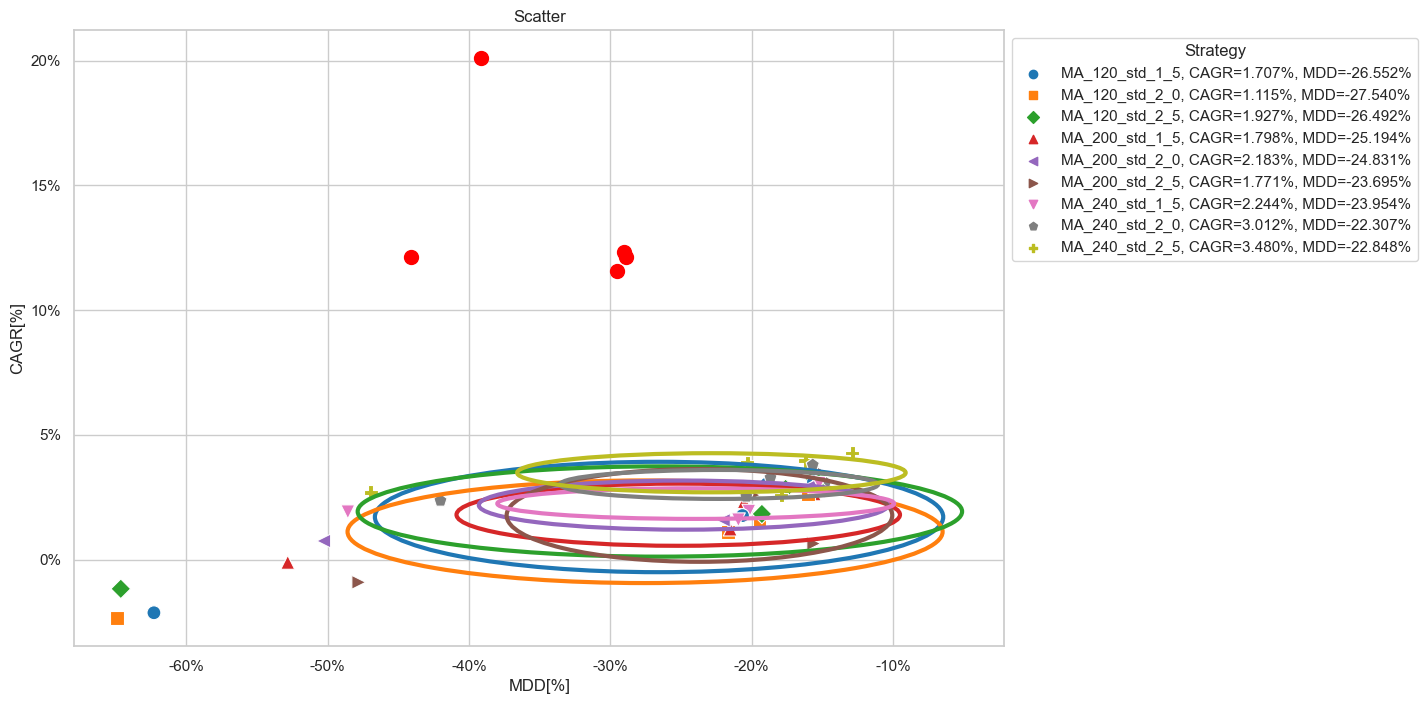

In [33]:
draw_strategy_scatter(n_bband_df, result_df)

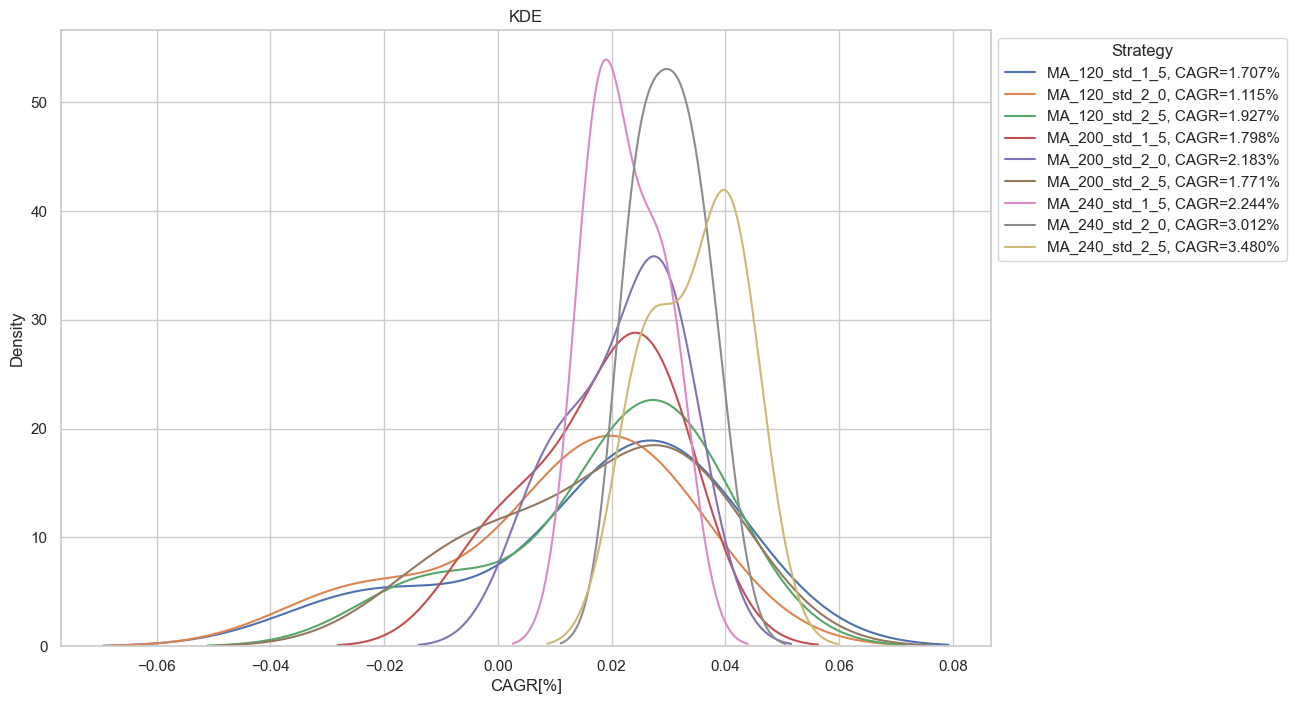

In [35]:
draw_strategy_kde(n_bband_df)

# 順勢布林通道
當收盤價突破上軌線時觸發進場條件，當收盤價跌破下軌線時觸發出場條件，可設定的參數為移動平均線及上下軌標準差。
1. 移動平均線 : 120、200、240日
2. 標準差 : 1.5、2、2.5倍標準差

In [23]:
close=data.get('price:close')

# 布林通道縮寫:bband
# 順勢用p代表
p_bband={}

for ma in [120, 200, 240]: # 移動平均線
    for dev in [1.5, 2.0, 2.5]: # 標準差
        p_bband[f'MA_{ma}_std_{dev}'.replace('.', '_')] = data.indicator('BBANDS', resample='D', nbdevup=float(dev), nbdevdn=float(dev), timeperiod=ma)

In [24]:
p_bband_conditions = {}
for f in factor_dict.keys():
    for k,v in p_bband.items():
        # 0:upperband
        # 1:middleband
        # 2:lowerband
        entries = close > v[0]
        exits = close < v[2]
        strategy = entries.hold_until(exits)
        p_bband_conditions[f'{k}&{f}'] = strategy & factor_dict[str(f)]

In [ ]:
p_bband_report_collection = sim_conditions(conditions=p_bband_conditions, resample='M', data=data, combination=False)
p_bband_df = p_bband_report_collection.stats.T
p_bband_df.index = p_bband_df.index.str.split('&', n=1, expand=True)
p_bband_df = p_bband_df.reset_index(names=['strategy', 'factor'])
split_columns = p_bband_df['strategy'].str.split('_', expand=True)
p_bband_df['MA'] = split_columns[1].astype(int)
p_bband_df['std'] = split_columns[3].astype(int) + (split_columns[4].astype(int)/10)

In [14]:
p_bband_df.to_csv('../Data/factor_strategy_result/p_bband_df.csv', encoding='utf-8-sig')

In [29]:
p_bband_df.sort_values(by=['CAGR'], ascending=False).head(10)

,strategy,factor,CAGR,daily_sharpe,max_drawdown,avg_drawdown,win_ratio,ytd,MA
23,MA_200_std_2_5,pb,0.037278,57.93,-0.203361,-0.110043,0.387183,0.015066,200
36,MA_120_std_1_5,p_ic,0.034123,79.50,-0.193618,-0.064636,0.454595,0.017799,120
27,MA_120_std_1_5,ps,0.034100,76.49,-0.193618,-0.055610,0.429675,0.030355,120
28,MA_120_std_2,ps,0.031405,81.81,-0.196510,-0.060928,0.428026,0.031655,120
37,MA_120_std_2,p_ic,0.031287,86.58,-0.196510,-0.077345,0.450382,0.019629,120
38,MA_120_std_2_5,p_ic,0.031149,85.67,-0.173883,-0.075168,0.445960,0.017942,120
1,MA_120_std_2,ev_s,0.028177,79.30,-0.291733,-0.100122,0.426301,0.027274,120
35,MA_240_std_2_5,ps,0.028102,89.43,-0.196510,-0.059037,0.399381,0.028212,240
30,MA_200_std_1_5,ps,0.027368,96.75,-0.193618,-0.063116,0.417508,0.030448,200
29,MA_120_std_2_5,ps,0.026779,90.58,-0.182503,-0.063019,0.417015,0.027839,120


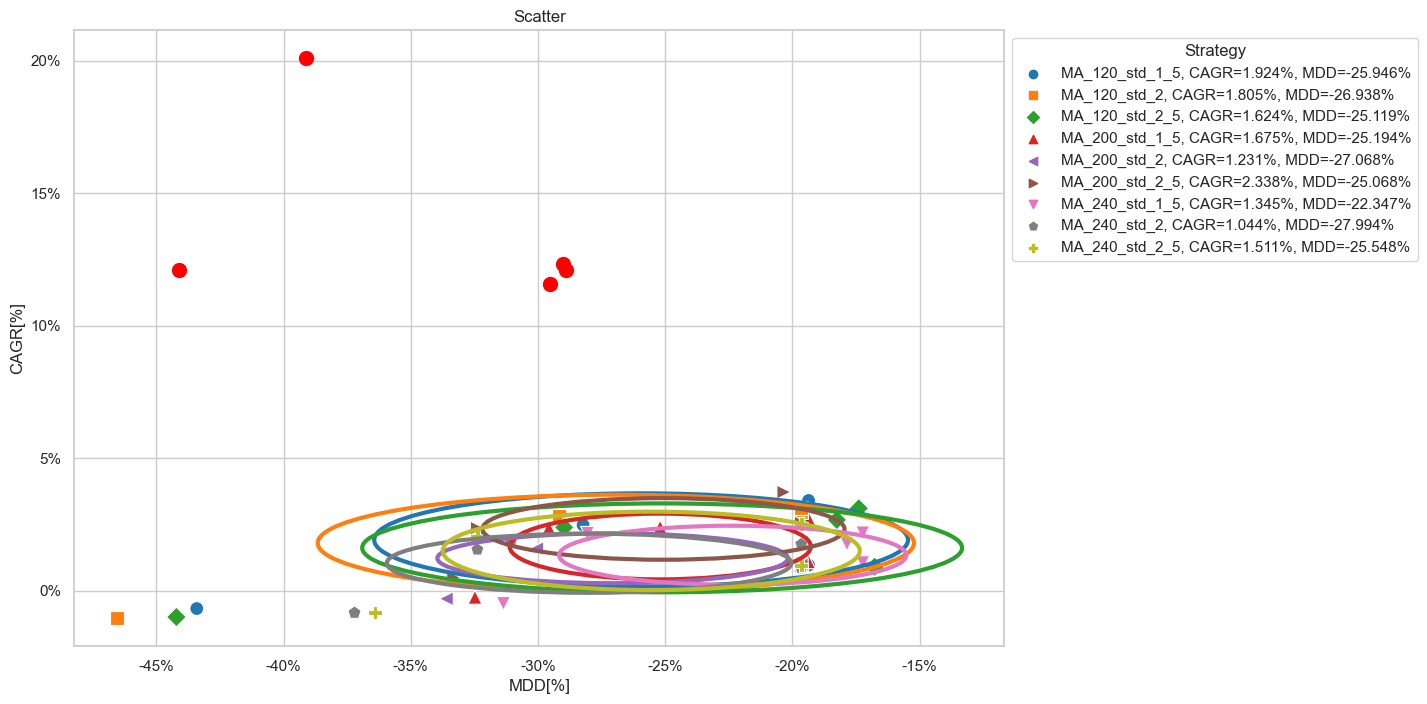

In [34]:
# D
draw_strategy_scatter(p_bband_df,result_df)

In [ ]:
draw_strategy_kde(p_bband_df)

# 逢低買進
同時考量價格與成交量的乖離，當收盤價跌破移動平均線且乖離超過設定比例，成交量突破平均成交量且乖離超過設定比例觸發進場條件，持有到窗格最後一天，可設定的參數為移動平均線、均線乖離、平均成交量天數、成交量乖離。
1. 移動平均線 : 20、40、60日，搭配10%均線乖離
2. 成交量 : 5日平均成交量，搭配50%及80%成交量乖離

In [37]:
close = data.get('price:close')
vol = data.get('price:volume')
vol.index = pd.to_datetime(vol.index)

buy_at_low_conditions={}

for f in factor_dict.keys():
    for price_ma in [20,40,60]:
        for vol_dev in [0.5, 0.8]:
            # 價格ma
            p_ma = close.average(price_ma)
            # 價格dev
            p_dev = (close - p_ma) / p_ma
            # 成交量ma
            v_ma = vol.average(5)
            # 成交量dev
            v_dev = (vol - v_ma) / v_ma
            entries = (close <= p_ma) & (abs(p_dev) >= 0.1) & (vol >= v_ma) & (abs(v_dev) >= vol_dev)
            exits = entries.resample('M').last()
            strategy = entries.hold_until(exits)

            buy_at_low_conditions[f'p_{price_ma}_0.1_v_5_{vol_dev}&{f}'.replace('.', '_')] = strategy & factor_dict[str(f)]
        

In [38]:
buy_at_low_report_collection = sim_conditions(conditions=buy_at_low_conditions, resample='M', data=data, combination=False)
buy_at_low_df = buy_at_low_report_collection.stats.T
buy_at_low_df.index = buy_at_low_df.index.str.split('&', n=1, expand=True)
buy_at_low_df = buy_at_low_df.reset_index(names=['strategy', 'factor'])
split_columns = buy_at_low_df['strategy'].str.split('_', expand=True)
buy_at_low_df['MA'] = split_columns[1].astype(int)
buy_at_low_df['std'] = split_columns[6].astype(int) + (split_columns[7].astype(int)/10)

Backtesting progress: 100%|██████████| 30/30 [00:19<00:00,  1.53condition/s]


In [13]:
buy_at_low_df.to_csv('../Data/factor_strategy_result/buy_at_low_df.csv', encoding='utf-8-sig')

In [39]:
buy_at_low_df.sort_values(by=['CAGR'], ascending=False).head(10)

,strategy,factor,CAGR,daily_sharpe,max_drawdown,avg_drawdown,win_ratio,ytd,MA,std
13,p_20_0_1_v_5_0_8,pb,0.025082,82.74,-0.188035,-0.081708,0.430730,0.011822,20,0.8
12,p_20_0_1_v_5_0_5,pb,0.024316,87.89,-0.191482,-0.085184,0.429755,0.011713,20,0.5
15,p_40_0_1_v_5_0_8,pb,0.023682,84.44,-0.190762,-0.087567,0.429891,0.012287,40,0.8
17,p_60_0_1_v_5_0_8,pb,0.022870,82.68,-0.188930,-0.093036,0.430616,0.013336,60,0.8
24,p_20_0_1_v_5_0_5,p_ic,0.020851,121.48,-0.316084,-0.070828,0.447911,0.012911,20,0.5
14,p_40_0_1_v_5_0_5,pb,0.020568,91.14,-0.193927,-0.095737,0.428950,0.012845,40,0.5
16,p_60_0_1_v_5_0_5,pb,0.018526,96.06,-0.198768,-0.095941,0.429438,0.010790,60,0.5
25,p_20_0_1_v_5_0_8,p_ic,0.017890,124.83,-0.317504,-0.071673,0.448954,0.013546,20,0.8
26,p_40_0_1_v_5_0_5,p_ic,0.016162,125.50,-0.308317,-0.070258,0.448691,0.013894,40,0.5
27,p_40_0_1_v_5_0_8,p_ic,0.015332,125.71,-0.306847,-0.071734,0.447192,0.011326,40,0.8


C:\Users\iplab\AppData\Local\Temp\ipykernel_13076\3397861958.py:15: UserWarning: The markers list has more values (9) than needed (6), which may not be intended.
  scatter_plot = sns.scatterplot(x='max_drawdown', y='CAGR', hue='strategy', style='strategy', markers=markers, s=100, data=df, palette='tab10')


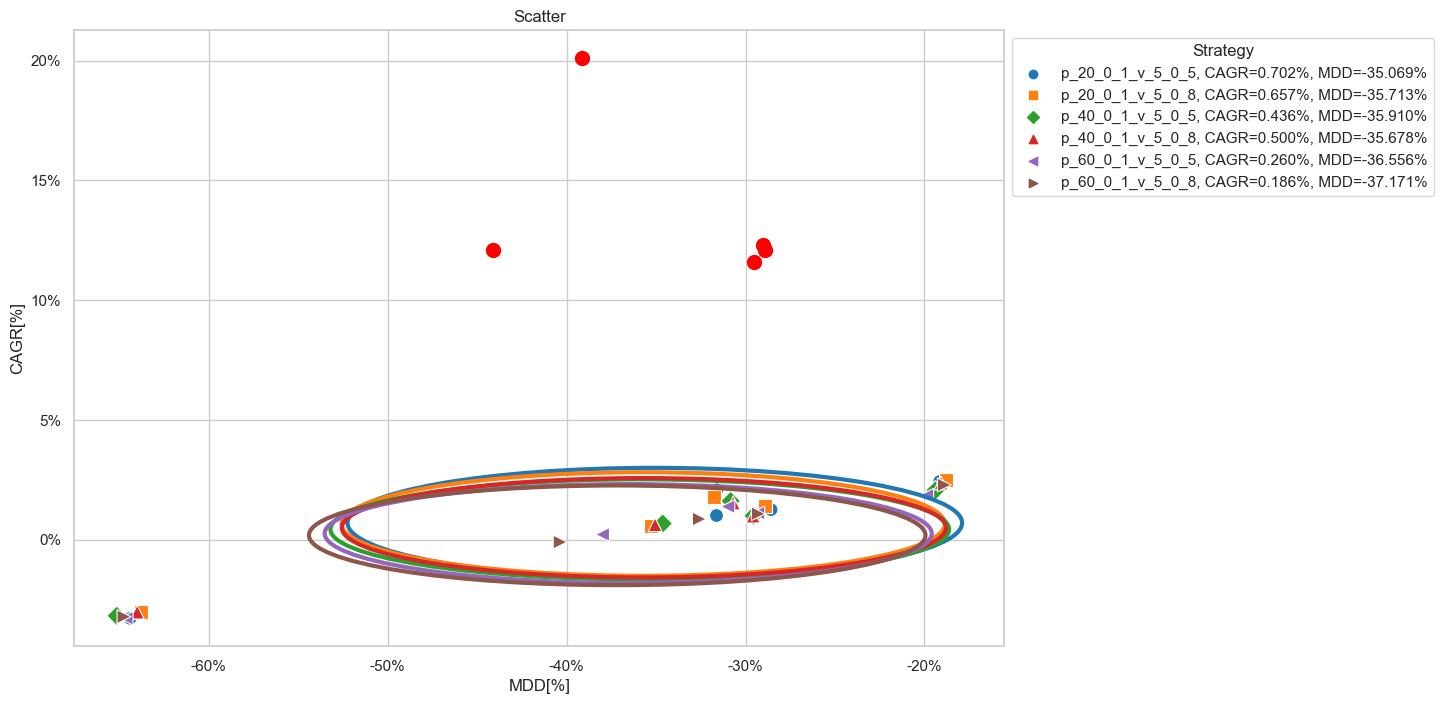

In [40]:
# D
draw_strategy_scatter(buy_at_low_df,result_df)

In [ ]:
draw_strategy_kde(buy_at_low_df)

# 逆勢高低通道
當收盤價跌破前數日低點時觸發進場條件，當收盤價突破前數日高點時觸發出場條件，可設定的參數為前數日的天數。
1. 前N日 : 100、120、200、240日

In [42]:
close = data.get('price:close')

hign_low_band_conditions={}

for f in factor_dict.keys():
    for ma in [100, 120, 200, 240]:
        # 前幾日最低點
        p_min = close.rolling(ma).min()
        # 前幾日最高點
        p_max = close.rolling(ma).max()

        entries = close > p_min
        exits = close < p_max
        strategy = entries.hold_until(exits)
        hign_low_band_conditions[f'ma_{ma}&{f}'] = strategy &  factor_dict[str(f)]

In [43]:
hign_low_band_report_collection = sim_conditions(conditions=hign_low_band_conditions, resample='M', data=data, combination=False)
hign_low_band_df = hign_low_band_report_collection.stats.T
hign_low_band_df.index = hign_low_band_df.index.str.split('&', n=1, expand=True)
hign_low_band_df = hign_low_band_df.reset_index(names=['strategy', 'factor'])
split_columns = hign_low_band_df['strategy'].str.split('_', expand=True)
hign_low_band_df['MA'] = split_columns[1].astype(int)

Backtesting progress: 100%|██████████| 20/20 [00:04<00:00,  4.44condition/s]


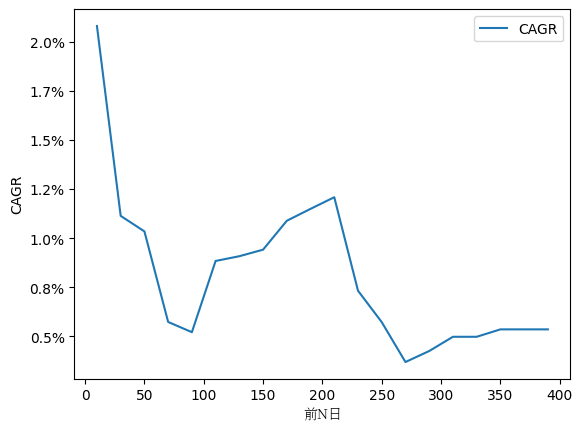

In [15]:
from matplotlib.ticker import FuncFormatter
from matplotlib.font_manager import FontProperties
ax = hign_low_band_df[['MA','CAGR']].groupby(['MA']).mean().reset_index().plot(x='MA', y='CAGR')

font = FontProperties(fname=r'NotoSerifTC-Light.otf')
plt.xlabel('前N日', fontproperties=font)
plt.ylabel('CAGR')

formatter = FuncFormatter(lambda x, _: '{:.1%}'.format(x))
ax.yaxis.set_major_formatter(formatter)

In [44]:
hign_low_band_df.sort_values(by=['CAGR'], ascending=False).head(5)

,strategy,factor,CAGR,daily_sharpe,max_drawdown,avg_drawdown,win_ratio,ytd,MA
0,ma_100,ev_s,0.030462,126.11,-0.270498,-0.121342,0.432203,0.014086,100
17,ma_120,p_ic,0.027677,80.54,-0.457310,-0.083587,0.486607,0.019116,120
12,ma_100,ps,0.026961,93.96,-0.330419,-0.093911,0.449393,0.085615,100
1,ma_120,ev_s,0.019887,175.61,-0.275911,-0.144888,0.427885,0.014276,120
16,ma_100,p_ic,0.017129,91.52,-0.508332,-0.099610,0.464000,0.018407,100


C:\Users\iplab\AppData\Local\Temp\ipykernel_13076\3397861958.py:15: UserWarning: The markers list has more values (9) than needed (4), which may not be intended.
  scatter_plot = sns.scatterplot(x='max_drawdown', y='CAGR', hue='strategy', style='strategy', markers=markers, s=100, data=df, palette='tab10')


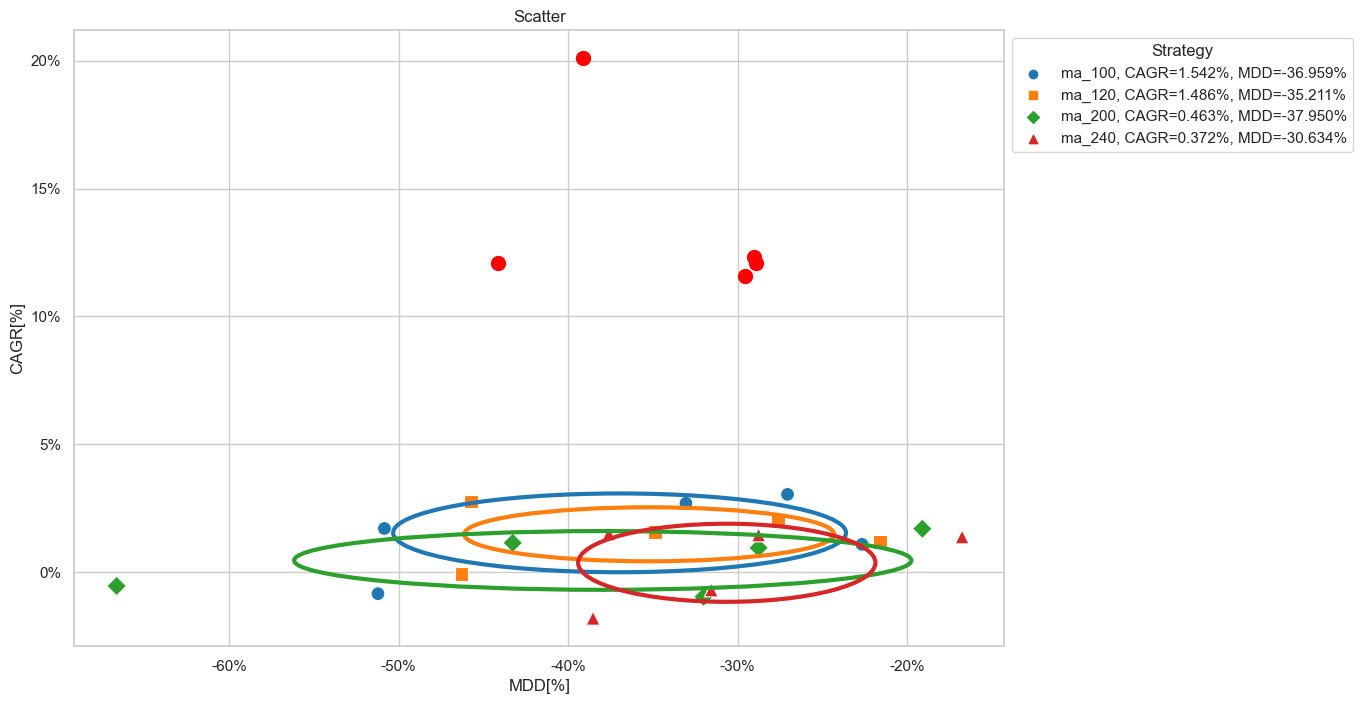

In [45]:
# D
draw_strategy_scatter(hign_low_band_df,result_df)

In [ ]:
draw_strategy_kde(hign_low_band_df)